In [1]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_IRE = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'Ireland')].copy()

In [3]:
df_DA_IRE['job_posted_month_no'] = df_DA_IRE['job_posted_date'].dt.month

In [4]:
df_DA_IRE_explode = df_DA_IRE.explode('job_skills')

In [5]:
df_DA_IRE_pivot = df_DA_IRE_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_IRE_pivot.loc['Total'] = df_DA_IRE_pivot.sum()

df_DA_IRE_pivot = df_DA_IRE_pivot[df_DA_IRE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_IRE_pivot = df_DA_IRE_pivot.drop('Total')

df_DA_IRE_pivot

job_skills,sql,excel,tableau,python,power bi,r,sas,azure,powerpoint,sql server,...,openstack,jquery,planner,smartsheet,slack,scala,splunk,spring,unity,terminal
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,81,45,41,45,26,22,34,14,9,8,...,1,1,1,0,1,0,0,1,0,0
2,33,13,13,20,10,11,6,6,6,0,...,0,0,0,0,0,1,0,0,0,0
3,39,29,19,19,20,12,2,10,11,2,...,0,0,0,0,0,0,1,0,0,0
4,27,22,22,18,15,12,4,8,9,7,...,0,0,0,0,0,0,0,0,0,1
5,36,28,21,20,25,9,8,5,2,8,...,0,0,0,0,0,0,0,0,0,0
6,31,28,29,17,17,15,8,2,4,8,...,0,0,0,0,0,0,0,0,0,0
7,35,29,27,23,24,20,0,7,4,5,...,0,0,0,0,0,0,0,0,0,0
8,32,25,17,12,19,11,6,3,5,2,...,0,0,0,0,0,0,0,0,0,0
9,22,14,12,16,15,9,4,10,2,6,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

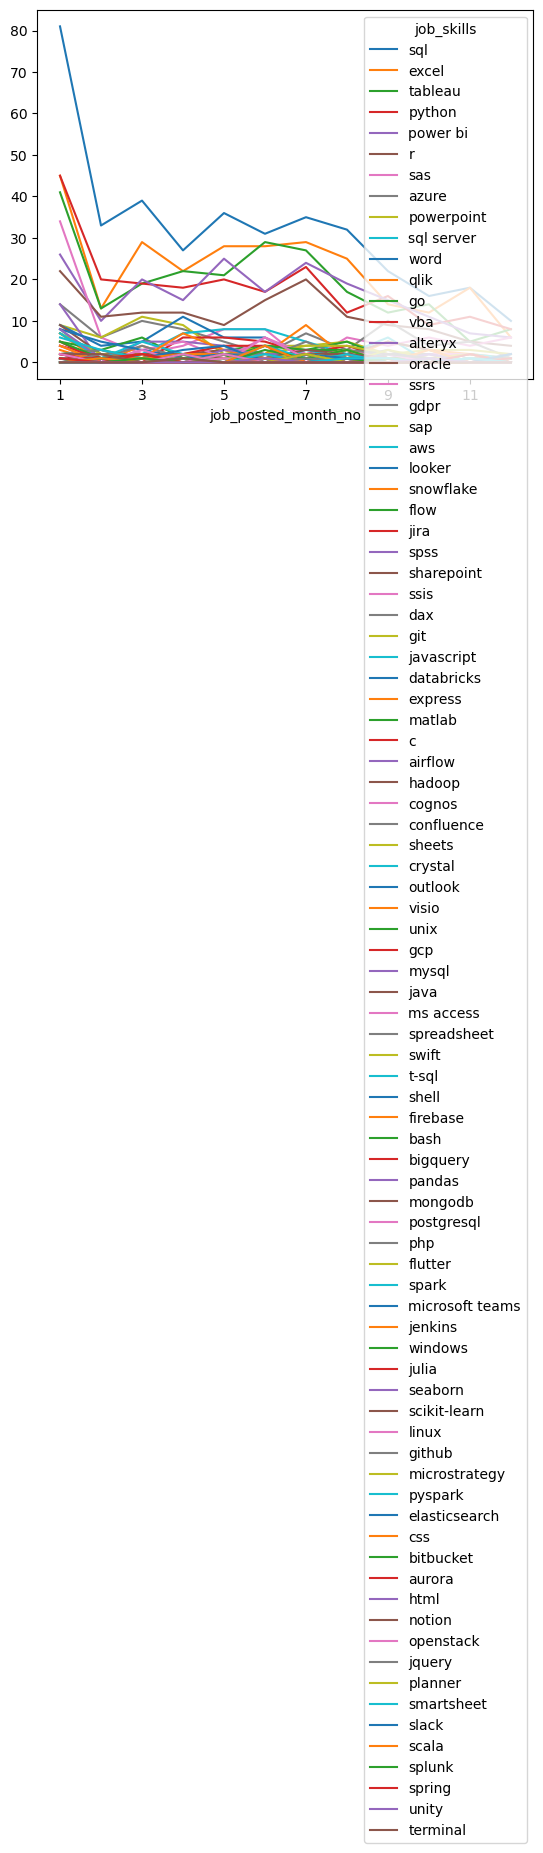

In [6]:
df_DA_IRE_pivot.plot(kind='line')

In [7]:
DA_totals = df_DA_IRE.groupby('job_posted_month_no').size()

In [8]:
df_DA_IRE_percent = df_DA_IRE_pivot.div(DA_totals/100, axis=0)

df_DA_IRE_percent

job_skills,sql,excel,tableau,python,power bi,r,sas,azure,powerpoint,sql server,...,openstack,jquery,planner,smartsheet,slack,scala,splunk,spring,unity,terminal
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,53.642384,29.801325,27.152318,29.801325,17.218543,14.569536,22.516556,9.271523,5.960265,5.298013,...,0.662252,0.662252,0.662252,0.000000,0.662252,0.000000,0.000000,0.662252,0.000000,0.000000
2,48.529412,19.117647,19.117647,29.411765,14.705882,16.176471,8.823529,8.823529,8.823529,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.470588,0.000000,0.000000,0.000000,0.000000
3,53.424658,39.726027,26.027397,26.027397,27.397260,16.438356,2.739726,13.698630,15.068493,2.739726,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.369863,0.000000,0.000000,0.000000
4,45.000000,36.666667,36.666667,30.000000,25.000000,20.000000,6.666667,13.333333,15.000000,11.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.666667
5,63.157895,49.122807,36.842105,35.087719,43.859649,15.789474,14.035088,8.771930,3.508772,14.035088,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,57.407407,51.851852,53.703704,31.481481,31.481481,27.777778,14.814815,3.703704,7.407407,14.814815,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,53.846154,44.615385,41.538462,35.384615,36.923077,30.769231,0.000000,10.769231,6.153846,7.692308,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,53.333333,41.666667,28.333333,20.000000,31.666667,18.333333,10.000000,5.000000,8.333333,3.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,59.459459,37.837838,32.432432,43.243243,40.540541,24.324324,10.810811,27.027027,5.405405,16.216216,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [9]:
# changes month number to month name
df_DA_IRE_percent = df_DA_IRE_percent.reset_index()
df_DA_IRE_percent['job_posted_month'] = df_DA_IRE_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_IRE_percent = df_DA_IRE_percent.set_index('job_posted_month')
df_DA_IRE_percent = df_DA_IRE_percent.drop(columns='job_posted_month_no')

df_DA_IRE_percent

job_skills,sql,excel,tableau,python,power bi,r,sas,azure,powerpoint,sql server,...,openstack,jquery,planner,smartsheet,slack,scala,splunk,spring,unity,terminal
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,53.642384,29.801325,27.152318,29.801325,17.218543,14.569536,22.516556,9.271523,5.960265,5.298013,...,0.662252,0.662252,0.662252,0.000000,0.662252,0.000000,0.000000,0.662252,0.000000,0.000000
Feb,48.529412,19.117647,19.117647,29.411765,14.705882,16.176471,8.823529,8.823529,8.823529,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.470588,0.000000,0.000000,0.000000,0.000000
Mar,53.424658,39.726027,26.027397,26.027397,27.397260,16.438356,2.739726,13.698630,15.068493,2.739726,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.369863,0.000000,0.000000,0.000000
Apr,45.000000,36.666667,36.666667,30.000000,25.000000,20.000000,6.666667,13.333333,15.000000,11.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.666667
May,63.157895,49.122807,36.842105,35.087719,43.859649,15.789474,14.035088,8.771930,3.508772,14.035088,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,57.407407,51.851852,53.703704,31.481481,31.481481,27.777778,14.814815,3.703704,7.407407,14.814815,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,53.846154,44.615385,41.538462,35.384615,36.923077,30.769231,0.000000,10.769231,6.153846,7.692308,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,53.333333,41.666667,28.333333,20.000000,31.666667,18.333333,10.000000,5.000000,8.333333,3.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,59.459459,37.837838,32.432432,43.243243,40.540541,24.324324,10.810811,27.027027,5.405405,16.216216,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


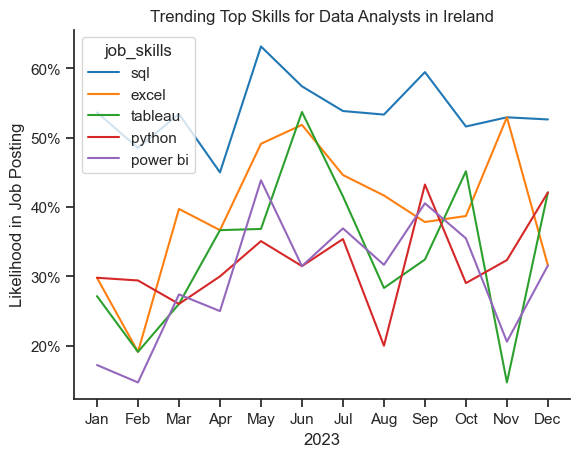

In [21]:
df_plot = df_DA_IRE_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() 

plt.title('Trending Top Skills for Data Analysts in Ireland')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()